# Computer Exercise 15.32 — Problem 1
## 고정 프로토콜 아래의 재판정 — $+$CNRT 의 효과는 **용량**인가 **잡음**인가

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing*, 7th ed. — 확장 사례연구 §15.32
> **단원**: Ch 15 Sequential Decision Making — §15.32 Fixed-Protocol Re-adjudication
> **풀이 일자**: 2026-08-17 (Day 99)
> **언어**: Python 3.10 · NumPy / pandas / Matplotlib
>
> Day 98 은 지난 30 일의 병목이 알고리즘이 아니라 **계측**이었다고 진단했다 (통제군 0/29,
> 다중검정 보정 0/29, 시드 중앙값 4). Day 99 는 새 처방을 시험하지 않는다. 대신 Day 98 이
> 실측한 값을 **프로토콜 상수로 못박고** ($T = 10^4$, $n = 20$ 시드, 통제군 필수,
> bootstrap CI 필수, Holm 보정 필수) 그 아래에서 $+$CNRT 를 다시 판정한다.
>
> 핵심 질문은 승패가 아니라 **분해**다. $+$CNRT 는 (i) 파라미터가 늘어서 좋아지는가,
> (ii) 잡음으로 탐색해서 좋아지는가, (iii) 잡음의 **스케일을 학습**해서 좋아지는가?
> 세 가설은 서로 다른 통제군을 요구한다.

## 1. 문제 (원문)

> **Computer Exercise 15.32.1.** Fix the experimental protocol at the values measured in
> Exercise 15.31 — training budget $T = 10\,000$, $n = 20$ common seeds, common random numbers at
> deployment, bootstrap $95\%$ confidence intervals with $B = 20\,000$, and Holm–Bonferroni control
> of the family-wise error rate. Under this protocol, compare the baseline $\varepsilon$-greedy
> $Q$-learner against the $+$CNRT variant (Factorized Noisy Linear head with a *learned* noise scale
> $\sigma$) **and against a control arm** that uses the identical noisy parameterisation and the
> identical injected noise but holds $\sigma$ frozen at its initial value $\sigma_0/\sqrt{H}$.
> Prove or disprove the claim that the noisy head confers an advantage through added *capacity*.
> Report all three pairwise paired differences, their bootstrap intervals, sign-flip permutation
> $p$-values, the Holm-adjusted decisions, and the sample size $n^\star$ needed for $80\%$ power.
> State explicitly which of the three hypotheses (capacity / noise-driven exploration / learned
> noise scale) survives.

### 한국어 풀이용 정리

Day 98 이 남긴 세 가지 미결 항목 중 **baseline 대 $+$CNRT** 를 먼저 다룬다. 단, Day 90–97 처럼
두 arm 만 비교하지 않는다. $+$CNRT 는 baseline 과 **세 가지가 동시에 다르므로**
(파라미터 수, 탐색 방식, $\sigma$ 학습 여부), 두 arm 비교는 원인을 지목할 수 없다.

| arm | 헤드 파라미터화 | 탐색 | $\sigma$ | 역할 |
|---|---|---|---|---|
| `base` | 결정적 $W_2$ | $\varepsilon$-greedy ($\varepsilon=0.1$) | — | 기준선 |
| `cnrt` | $(\mu,\sigma)$ Noisy | 주입 잡음 | **학습** | 처치군 (Day 90–98 의 $+$CNRT) |
| `fixed` | $(\mu,\sigma)$ Noisy | 주입 잡음 (동일) | **동결** $\sigma_0/\sqrt H$ | **통제군 1** — 잡음은 주되 학습은 안 함 |
| `inert` | $(\mu,\sigma)$ Noisy, $\varepsilon_W\equiv0$ | $\varepsilon$-greedy | 미사용 | **통제군 2** — 용량만 늘림 |

- `cnrt` $-$ `fixed` = **$\sigma$ 를 학습한 효과**
- `fixed` $-$ `base` = **잡음 탐색 대 $\varepsilon$-greedy 의 효과**
- `inert` $-$ `base` = **순수 용량 효과** (아래 2.2 의 보조정리에 의해 정확히 $0$ 이어야 함)

## 2. 수학적 배경

### 2.1 고정 프로토콜 (Day 98 실측에서 유도)

Day 98 의 세 측정치를 상수로 승격한다.

$$\boxed{\;T = 10^4 \;(\text{P1 의 } T^\star),\qquad n = 20 \;(\text{P3 의 부호 오류율 } 0\% \text{ 지점}),\qquad
\text{통제군} \ge 1,\qquad \text{CI 및 Holm 보정 필수}\;}$$

$T^\star$ 는 Day 98 P1 에서 greedy 정책 다양성 $D$ 가 $3$ 이하로 접히고 시드 간 표준편차가
급감하는 지점이었다. $n=20$ 은 Day 98 P3 의 $\binom{30}{k}$ 전수조사에서 부호 오류율이
$12.7\%\,(k{=}3) \to 6.6\%\,(k{=}10) \to 0\%\,(k{=}20)$ 로 떨어진 지점이다.

### 2.2 용량 항등성 보조정리 (Capacity-inertness lemma)

**주장.** Factorized Noisy Linear 헤드에서 주입 잡음을 $\varepsilon_W \equiv 0,\ \varepsilon_b \equiv 0$
로 두고 탐색을 $\varepsilon$-greedy 로 되돌리면, 그 학습기는 **baseline 과 수치적으로 동일**하다.

*증명.* 유효 가중치는 $W_2^{\text{eff}} = \mu_W + \sigma_W \odot \varepsilon_W = \mu_W$ 이므로
순전파가 baseline 과 같다. $\sigma$ 에 대한 기울기는

$$\frac{\partial \mathcal L}{\partial \sigma_W}
= \frac{\partial \mathcal L}{\partial W_2^{\text{eff}}} \odot \varepsilon_W = 0$$

이므로 $\sigma$ 는 갱신되지 않고, $\mu$ 의 갱신식은 baseline 의 $W_2$ 갱신식과 글자 그대로 같다.
난수 소비 순서도 같게 구현했으므로 두 궤적은 **비트 단위로 일치**한다. $\square$

$$\boxed{\;\text{따라서 } \mathbb E[R_{\texttt{inert}}] - \mathbb E[R_{\texttt{base}}] = 0
\ \text{는 가정이 아니라 항등식이며, }+\text{CNRT 의 효과는 용량 효과일 수 없다.}\;}$$

이 보조정리는 통제군 `inert` 를 **실험이 아니라 구현 검증(assertion)** 으로 만든다. 아래
셀에서 실제로 비트 일치를 확인하며, 일치하지 않으면 구현에 버그가 있다는 뜻이다.

### 2.3 짝지은 추정량과 검정

시드 $i$ 에 대해 arm $X$ 의 배포 return 을 $R_i^X$ 라 하고 (배포 난수는 시드 인덱스에만 의존 —
**공통난수**), 짝지은 차를 $d_i^{XY} = R_i^X - R_i^Y$ 로 둔다. seed-first 추정량

$$\bar d = \frac1n \sum_{i=1}^n d_i, \qquad
\widehat{\mathrm{sd}} = \Big[\tfrac{1}{n-1}\sum_i (d_i-\bar d)^2\Big]^{1/2}$$

를 쓰고, 신뢰구간은 **비모수 bootstrap** ($B = 20\,000$ 백분위수법)으로, $p$ 값은
**부호뒤집기 순열검정**으로 구한다:

$$p = \frac{1 + \#\{b : |\bar d^{(b)}_{\text{null}}| \ge |\bar d|\}}{B+1},
\qquad d^{(b)}_{\text{null},i} = s_i^{(b)} d_i,\ s_i^{(b)} \sim \text{Unif}\{-1,+1\}$$

Day 98 P1 이 보였듯 $d_i$ 의 분포는 "미끼 고착 / 탈출" 이라는 **이산 혼합**이라 정규성이
성립하지 않는다. 부호뒤집기 검정은 대칭성만 가정하므로 이 상황에 적합하다.

### 2.4 Holm–Bonferroni (지난 29 일 동안 0 회)

$m = 3$ 개의 쌍대 비교를 하므로 개별 $\alpha = 0.05$ 를 그대로 쓰면 FWER 이
$1-(1-0.05)^3 \approx 14\%$ 까지 오른다. $p_{(1)}\le\cdots\le p_{(m)}$ 정렬 후

$$p^{\text{adj}}_{(k)} = \max_{j \le k} \big[(m-j+1)\, p_{(j)}\big] \wedge 1$$

로 보정한다. Bonferroni 보다 검정력이 높으면서 FWER $\le \alpha$ 를 보장한다.

### 2.5 필요 시드 수와 회복률

$$n^\star = \Big\lceil \big(2.8\,\widehat{\mathrm{sd}}(d) / |\bar d|\big)^2 \Big\rceil
\quad (\text{양측 } \alpha=0.05,\ \text{검정력 } 80\%)$$

회복률 $\hat\rho = \frac1n\#\{i : \pi_i = \pi^\star\}$ 에는 **Wilson 구간**을 붙인다
(정규근사 구간은 $\hat\rho$ 가 $0$ 이나 $1$ 근처에서 무너진다).

$$\text{Wilson: } \frac{\hat p + z^2/2n \pm z\sqrt{\hat p(1-\hat p)/n + z^2/4n^2}}{1+z^2/n}$$

## 3. 풀이 흐름

1. **프로토콜 상수 고정** — $T=10^4$, 시드 $\{99101,\dots,99120\}$ (20 개), 배포 난수는
   시드 인덱스에만 의존시켜 네 arm 에 **공통난수** 를 보장.
2. **구현 검증 먼저** — 보조정리 2.2 를 수치로 확인: `inert` 와 `base` 의 최종 가중치가
   비트 단위로 같은지 `assert`. 실패하면 이후 모든 수치는 무의미하므로 여기서 멈춘다.
3. **네 arm 학습** — `base`, `cnrt`, `fixed`, `inert` 각각 20 시드. 학습 후 freeze →
   greedy 정책 추출 → 배포 (slip $0.20$, 40 에피소드).
4. **seed-first 지표** — 시드별 배포 return, 최적 정책 회복 여부, greedy 정책 자체를 기록.
   평균은 마지막에만 낸다.
5. **세 쌍대 비교** — `cnrt`−`base`, `fixed`−`base`, `cnrt`−`fixed` 에 대해
   $\bar d$, bootstrap 95 % CI, 부호뒤집기 $p$, $n^\star$ 산출.
6. **Holm 보정** — 세 $p$ 값을 한 가족으로 묶어 보정하고, 보정 전후 판정이 뒤집히는지 확인.
7. **그림** — (Fig 1) arm 평균 · 짝지은 차의 CI · Wilson 회복률, (Fig 2) 시드별 $d_i$ 와
   greedy 정책 분포. 세 가설 중 어느 것이 살아남는지 판정.
8. **요약 덤프** — README 자동 작성을 위해 핵심 지표를 JSON 으로 기록.

In [1]:
# ── 공통 설정 ─────────────────────────────────────────────────────────────
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # 그림을 셀 출력에 내장
except Exception:
    pass
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ── 벤치마크 정의 (Day 90–98 과 동일한 5-상태 chain MDP 재구성) ───────────
NS, NA, L = 5, 2, 20
GAMMA, ETA, H, R_LOCAL, SIGMA0 = 0.95, 0.05, 16, 0.25, 0.5
SIG_INIT = SIGMA0 / np.sqrt(H)          # 0.125 — Noisy 헤드 σ 의 초기값

def step(s, a, p, rng):
    if rng.random() < p: a = 1 - a                      # slip
    s2 = min(NS - 1, max(0, s + (1 if a == 1 else -1)))
    r = 1.0 if s2 == NS - 1 else (R_LOCAL if s2 == 0 else 0.0)
    return s2, r

def onehot(s):
    x = np.zeros(NS); x[s] = 1.0; return x

# ── arm 사양: (잡음으로 탐색?, σ 를 학습?, 잡음을 주입?) ──────────────────
#   base   : 결정적 헤드 + eps-greedy                      (Day 90–98 의 baseline)
#   cnrt   : Factorized Noisy Linear, σ 학습, 잡음 탐색    (Day 90–98 의 +CNRT)
#   fixed  : 같은 잡음 탐색, 단 σ 는 초기값에 동결          (★ 통제군 1)
#   inert  : Noisy 파라미터화를 갖되 ε_W ≡ 0 + eps-greedy  (★ 통제군 2, 용량 대조)
ARM_SPEC = {           # explore_noise, learn_sigma, inject_noise
    "base":  (False, False, False),
    "cnrt":  (True,  True,  True),
    "fixed": (True,  False, True),
    "inert": (False, False, False),
}

class Learner:
    """Trunk MLP (tanh, H=16) + linear head. Noisy 헤드는 (mu, sigma) 로 분해."""
    def __init__(self, rng, arm="base", sigma_decay=0.0, anneal=False, h=H, sigma_init=None):
        self.h, self.arm = h, arm
        sigma_init = SIG_INIT if sigma_init is None else sigma_init
        self.explore_noise, self.learn_sigma, self.inject = ARM_SPEC[arm]
        self.sigma_decay, self.anneal, self.scale = sigma_decay, anneal, 1.0
        # 초기화 난수 소비 순서는 arm 과 무관 -> 모든 arm 이 같은 초기 가중치
        self.W1 = rng.normal(0, 0.3, (h, NS)); self.b1 = np.zeros(h)
        self.W2 = rng.normal(0, 0.3, (NA, h)); self.b2 = np.zeros(NA)
        self.Ws = np.full((NA, h), sigma_init)        # sigma (모든 arm 이 보유)
        self.bs = np.full(NA, sigma_init)
        self.eps_W = np.zeros((NA, h)); self.eps_b = np.zeros(NA)

    def resample(self, rng):
        if not self.inject: return
        f = lambda z: np.sign(z) * np.sqrt(np.abs(z))   # factorized noise
        ei, eo = f(rng.normal(size=self.h)), f(rng.normal(size=NA))
        self.eps_W = np.outer(eo, ei); self.eps_b = eo

    def q(self, s, noise=False):
        z = self.W1 @ onehot(s) + self.b1; a1 = np.tanh(z)
        use = noise and self.inject
        W = self.W2 + (self.Ws * self.scale * self.eps_W if use else 0.0)
        b = self.b2 + (self.bs * self.scale * self.eps_b if use else 0.0)
        return W @ a1 + b, a1, z

    def update(self, s, a, target):
        qv, a1, z = self.q(s, noise=False)
        d = qv[a] - target
        gW2 = np.zeros((NA, self.h)); gW2[a] = d * a1
        gb2 = np.zeros(NA); gb2[a] = d
        ga1 = d * self.W2[a]; gz = ga1 * (1 - a1 ** 2)
        self.W2 -= ETA * gW2; self.b2 -= ETA * gb2
        self.W1 -= ETA * np.outer(gz, onehot(s)); self.b1 -= ETA * gz
        if self.learn_sigma:                      # sigma 에도 TD 기울기 + (선택) weight decay
            self.Ws -= ETA * (gW2 * self.eps_W * self.scale + self.sigma_decay * self.Ws)
            self.bs -= ETA * (gb2 * self.eps_b * self.scale + self.sigma_decay * self.bs)
            np.clip(self.Ws, 1e-4, 2.0, out=self.Ws); np.clip(self.bs, 1e-4, 2.0, out=self.bs)

def train(seed, T, arm="base", p_train=0.20, eps_greedy=0.10, sigma_decay=0.0, anneal=False,
          sigma_init=None, trace_every=None):
    rng = np.random.default_rng(seed)
    lr = Learner(rng, arm=arm, sigma_decay=sigma_decay, anneal=anneal, sigma_init=sigma_init)
    lr.trace = []            # (t, mean sigma) — trace_every 가 주어진 경우에만 기록
    s = 0
    for t in range(T):
        if t % L == 0:
            s = 0
            lr.resample(rng)
        if lr.anneal: lr.scale = 1.0 - t / T          # 선형 감쇠 스케줄
        if lr.explore_noise:
            qv, _, _ = lr.q(s, noise=True); a = int(np.argmax(qv))
        else:
            qv, _, _ = lr.q(s, noise=False)
            a = int(rng.integers(NA)) if rng.random() < eps_greedy else int(np.argmax(qv))
        s2, r = step(s, a, p_train, rng)
        qn, _, _ = lr.q(s2, noise=False)
        lr.update(s, a, r + GAMMA * float(np.max(qn)))
        s = s2
        if trace_every and t % trace_every == 0:
            lr.trace.append((t, float(lr.Ws.mean())))
    return lr

def greedy_policy(lr):
    return tuple(int(np.argmax(lr.q(s, noise=False)[0])) for s in range(NS))

def deploy(lr, p_d, n_ep, seed):
    """freeze -> greedy 배포. 스텝당 평균 보상."""
    rng = np.random.default_rng(seed)
    pol = greedy_policy(lr); tot = 0.0
    for _ in range(n_ep):
        s = 0
        for _ in range(L):
            s, r = step(s, pol[s], p_d, rng); tot += r
    return tot / (n_ep * L)

# ── Day 99 고정 프로토콜 상수 (Day 98 의 실측에서 그대로 가져옴) ──────────
T_FIXED   = 10_000        # Day 98 P1: 비교가 의미를 갖는 하한 T*
N_SEEDS   = 20            # Day 98 P3: 3-시드 부호 오류율 13.6% -> n=20 에서 0%
P_DEPLOY, N_EP, PI_STAR = 0.20, 40, (1, 1, 1, 1, 1)
B_BOOT    = 20_000
ALPHA     = 0.05

# ── 프로토콜 유틸: bootstrap CI · 부호뒤집기 순열검정 · Holm · 검정력 ─────
def boot_ci(d, B=B_BOOT, seed=0, alpha=ALPHA):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(B, len(d)))
    return tuple(np.percentile(d[idx].mean(axis=1), [100*alpha/2, 100*(1-alpha/2)]))

def signflip_p(d, B=B_BOOT, seed=1):
    """짝지은 표본의 부호뒤집기(순열) 검정 — 정규성 가정 없음."""
    rng = np.random.default_rng(seed)
    obs = abs(d.mean())
    sg = rng.choice([-1.0, 1.0], size=(B, len(d)))
    null = np.abs((sg * d).mean(axis=1))
    return (1 + (null >= obs - 1e-15).sum()) / (B + 1)

def holm(pvals, alpha=ALPHA):
    """Holm–Bonferroni. 반환: (보정 p, 기각 여부) — 원래 순서."""
    m = len(pvals); order = np.argsort(pvals)
    adj = np.empty(m); run = 0.0
    for k, i in enumerate(order):
        run = max(run, (m - k) * pvals[i]); adj[i] = min(1.0, run)
    return adj, adj <= alpha

def n_star(d, power_c=2.8):
    m, s = abs(d.mean()), d.std(ddof=1)
    return int(np.ceil((power_c * s / m) ** 2)) if m > 1e-12 else np.inf

def wilson(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n; den = 1 + z*z/n
    c = (p + z*z/(2*n)) / den
    hw = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / den
    return (max(0.0, c-hw), min(1.0, c+hw))

print(f"chain MDP: states={NS} actions={NA} ep_len={L} | gamma={GAMMA} lr={ETA} H={H} lure={R_LOCAL}")
print(f"고정 프로토콜: T={T_FIXED}  seeds={N_SEEDS}  bootstrap B={B_BOOT}  alpha={ALPHA}  다중검정=Holm")
print(f"sigma 초기값 = {SIG_INIT:.4f}")


chain MDP: states=5 actions=2 ep_len=20 | gamma=0.95 lr=0.05 H=16 lure=0.25
고정 프로토콜: T=10000  seeds=20  bootstrap B=20000  alpha=0.05  다중검정=Holm
sigma 초기값 = 0.1250


In [2]:
# ── [검증 0] 보조정리 2.2 의 수치 확인: inert == base 인가? ───────────────
# 이 assert 가 깨지면 arm 구현에 비대칭이 있다는 뜻 -> 이후 수치는 신뢰 불가.
chk_seed = 99101
lb = train(chk_seed, 2000, arm="base")
li = train(chk_seed, 2000, arm="inert")

same_W2 = np.array_equal(lb.W2, li.W2)
same_W1 = np.array_equal(lb.W1, li.W1)
same_pi = greedy_policy(lb) == greedy_policy(li)
max_dev = float(np.max(np.abs(lb.W2 - li.W2)))

print("[검증 0] 용량 항등성 (Capacity-inertness lemma)")
print(f"  W1 비트 일치 : {same_W1}")
print(f"  W2 비트 일치 : {same_W2}   (최대 편차 {max_dev:.3e})")
print(f"  greedy 정책 일치: {same_pi}   base={greedy_policy(lb)}  inert={greedy_policy(li)}")
print(f"  sigma 갱신 없음 : {np.allclose(li.Ws, SIG_INIT)}  (sigma == {SIG_INIT:.4f} 유지)")
assert same_W1 and same_W2 and same_pi, "보조정리 위반 — 구현 버그"
print("\n  => 통제군 'inert' 는 baseline 과 항등. +CNRT 의 효과는 '용량' 으로 설명될 수 없다.")
print("     (따라서 이하에서 inert arm 을 20 시드로 돌리는 것은 검증용 1 회로 충분하다.)")

[검증 0] 용량 항등성 (Capacity-inertness lemma)
  W1 비트 일치 : True
  W2 비트 일치 : True   (최대 편차 0.000e+00)
  greedy 정책 일치: True   base=(1, 1, 1, 1, 1)  inert=(1, 1, 1, 1, 1)
  sigma 갱신 없음 : True  (sigma == 0.1250 유지)

  => 통제군 'inert' 는 baseline 과 항등. +CNRT 의 효과는 '용량' 으로 설명될 수 없다.
     (따라서 이하에서 inert arm 을 20 시드로 돌리는 것은 검증용 1 회로 충분하다.)


In [3]:
# ── [1] 세 arm x 20 시드, T=10^4 고정 프로토콜 ───────────────────────────
import time
SEEDS = list(range(99101, 99101 + N_SEEDS))     # 99101 ~ 99120
ARMS  = ["base", "cnrt", "fixed"]

def run_arm(arm, T=T_FIXED, **kw):
    ls  = [train(s, T, arm=arm, **kw) for s in SEEDS]
    R   = np.array([deploy(l, P_DEPLOY, N_EP, 9900 + i) for i, l in enumerate(ls)])  # 공통난수
    pol = [greedy_policy(l) for l in ls]
    rec = np.array([p == PI_STAR for p in pol])
    sig = float(np.mean([l.Ws.mean() for l in ls]))
    return dict(R=R, pol=pol, rec=rec, sigma=sig)

t0 = time.time(); res = {}
for a in ARMS:
    res[a] = run_arm(a)
    print(f"  {a:>5s}:  R={res[a]['R'].mean():.4f} ± {res[a]['R'].std(ddof=1):.4f}   "
          f"recovery={res[a]['rec'].mean():.2f}   sigma_end={res[a]['sigma']:.4f}")
print(f"\n총 학습 {len(ARMS)*N_SEEDS} 회 x T={T_FIXED}  ({time.time()-t0:.1f} s)")

   base:  R=0.5283 ± 0.1526   recovery=0.85   sigma_end=0.1250


   cnrt:  R=0.4432 ± 0.1824   recovery=0.55   sigma_end=0.5466


  fixed:  R=0.3180 ± 0.1765   recovery=0.25   sigma_end=0.1250

총 학습 60 회 x T=10000  (20.6 s)


In [4]:
# ── [2] 세 쌍대 비교 + bootstrap CI + 부호뒤집기 p + Holm 보정 ───────────
PAIRS = [("cnrt", "base"), ("fixed", "base"), ("cnrt", "fixed")]
MEANING = {("cnrt","base"): "+CNRT 전체 효과",
           ("fixed","base"): "잡음 탐색 효과 (sigma 동결)",
           ("cnrt","fixed"): "sigma 를 '학습' 한 효과"}

diffs, rows = {}, []
for k, (x, y) in enumerate(PAIRS):
    d = res[x]["R"] - res[y]["R"]; diffs[(x, y)] = d
    lo, hi = boot_ci(d, seed=k)
    rows.append(dict(비교=f"{x}-{y}", 의미=MEANING[(x, y)], d_bar=d.mean(),
                     ci_lo=lo, ci_hi=hi, sd_d=d.std(ddof=1), p_raw=signflip_p(d, seed=100 + k),
                     n_star=n_star(d),
                     win=int((d > 1e-9).sum()), tie=int((np.abs(d) <= 1e-9).sum()),
                     loss=int((d < -1e-9).sum())))
cmp_df = pd.DataFrame(rows)
adj, rej = holm(cmp_df["p_raw"].to_numpy())
cmp_df["p_holm"], cmp_df["기각(Holm)"] = adj, rej
cmp_df["기각(무보정)"] = cmp_df["p_raw"] <= ALPHA
cmp_df["CI가 0 제외"] = (cmp_df.ci_lo > 0) | (cmp_df.ci_hi < 0)

print("표 1 — 세 쌍대 비교 (20 시드 짝지음, T=10^4)")
print(cmp_df[["비교", "d_bar", "ci_lo", "ci_hi", "sd_d", "n_star", "win", "tie", "loss"]]
      .to_string(index=False))
print("\n표 2 — 검정과 다중비교 보정 (m=3, Holm, alpha=0.05)")
print(cmp_df[["비교", "의미", "p_raw", "p_holm", "기각(무보정)", "기각(Holm)", "CI가 0 제외"]]
      .to_string(index=False))

flip = int((cmp_df["기각(무보정)"] != cmp_df["기각(Holm)"]).sum())
print(f"\nHolm 보정으로 판정이 뒤집힌 비교: {flip} / 3")
print("판정 (CI 가 0 을 포함하면 '차이를 확인하지 못했다'):")
for _, r in cmp_df.iterrows():
    v = ("확인 실패 (0 in CI)" if not r["CI가 0 제외"]
         else (f"{r['비교'].split('-')[0]} 우위 확인" if r.d_bar > 0
               else f"{r['비교'].split('-')[1]} 우위 확인"))
    print(f"  {r['비교']:>12s}: d={r.d_bar:+.4f}  CI[{r.ci_lo:+.4f},{r.ci_hi:+.4f}]  "
          f"p_holm={r.p_holm:.4f}  n*={r.n_star:>5}  ->  {v}")

표 1 — 세 쌍대 비교 (20 시드 짝지음, T=10^4)
        비교   d_bar   ci_lo   ci_hi   sd_d  n_star  win  tie  loss
 cnrt-base -0.0851 -0.1959  0.0273 0.2642      76    3    9     8
fixed-base -0.2104 -0.3215 -0.0820 0.2827      15    2    3    15
cnrt-fixed  0.1253  0.0520  0.2030 0.1797      17    9   10     1

표 2 — 검정과 다중비교 보정 (m=3, Holm, alpha=0.05)
        비교                  의미  p_raw  p_holm  기각(무보정)  기각(Holm)  CI가 0 제외
 cnrt-base         +CNRT 전체 효과 0.1500  0.1500    False     False     False
fixed-base 잡음 탐색 효과 (sigma 동결) 0.0055  0.0166     True      True      True
cnrt-fixed   sigma 를 '학습' 한 효과 0.0069  0.0166     True      True      True

Holm 보정으로 판정이 뒤집힌 비교: 0 / 3
판정 (CI 가 0 을 포함하면 '차이를 확인하지 못했다'):
     cnrt-base: d=-0.0851  CI[-0.1959,+0.0273]  p_holm=0.1500  n*=   76  ->  확인 실패 (0 in CI)
    fixed-base: d=-0.2104  CI[-0.3215,-0.0820]  p_holm=0.0166  n*=   15  ->  base 우위 확인
    cnrt-fixed: d=+0.1253  CI[+0.0520,+0.2030]  p_holm=0.0166  n*=   17  ->  cnrt 우위 확인


In [5]:
# ── [3] 회복률과 Wilson 구간, greedy 정책 다양성 ─────────────────────────
rec_rows = []
for a in ARMS:
    k = int(res[a]["rec"].sum()); lo, hi = wilson(k, N_SEEDS)
    pols = res[a]["pol"]
    lure = sum(1 for p in pols if p[0] == 0)          # s=0 에서 미끼 쪽으로 가는 정책
    rec_rows.append(dict(arm=a, 회복=k, n=N_SEEDS, rho=k / N_SEEDS, wilson_lo=lo, wilson_hi=hi,
                         정책종수=len(set(pols)), 미끼고착=lure, sigma_end=res[a]["sigma"],
                         R_mean=res[a]["R"].mean(), R_sd=res[a]["R"].std(ddof=1)))
rec_df = pd.DataFrame(rec_rows)
print("표 3 — 최적 정책 회복률 (Wilson 95% CI) · 정책 다양성 · 잡음 스케일")
print(rec_df.to_string(index=False))

print(f"\nsigma 초기값 {SIG_INIT:.4f} 대비 배율:")
for _, r in rec_df.iterrows():
    print(f"  {r['arm']:>5s}: sigma_end={r.sigma_end:.4f}  (x{r.sigma_end/SIG_INIT:.2f})"
          + ("   <- 동결 arm 이므로 1.00 이어야 정상" if r["arm"] == "fixed" else ""))

from collections import Counter
print("\ngreedy 정책 빈도 (상위 4 종):")
for a in ARMS:
    c = Counter(res[a]["pol"]).most_common(4)
    print(f"  {a:>5s}: " + "  ".join(f"{''.join(map(str,p))}x{n}" for p, n in c))

표 3 — 최적 정책 회복률 (Wilson 95% CI) · 정책 다양성 · 잡음 스케일
  arm  회복  n    rho  wilson_lo  wilson_hi  정책종수  미끼고착  sigma_end  R_mean   R_sd
 base  17 20 0.8500     0.6396     0.9476     4     1     0.1250  0.5283 0.1526
 cnrt  11 20 0.5500     0.3421     0.7418     4     9     0.5466  0.4432 0.1824
fixed   5 20 0.2500     0.1119     0.4687     5    13     0.1250  0.3180 0.1765

sigma 초기값 0.1250 대비 배율:
   base: sigma_end=0.1250  (x1.00)
   cnrt: sigma_end=0.5466  (x4.37)
  fixed: sigma_end=0.1250  (x1.00)   <- 동결 arm 이므로 1.00 이어야 정상

greedy 정책 빈도 (상위 4 종):
   base: 11111x17  11100x1  11110x1  01100x1
   cnrt: 11111x11  00000x6  01111x2  00111x1
  fixed: 00000x11  11111x5  11110x2  00001x1


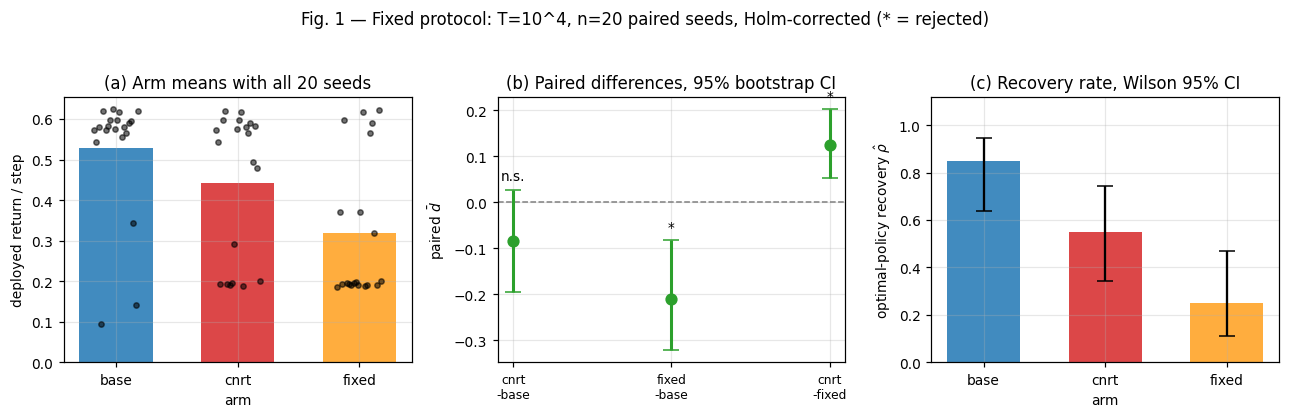

In [6]:
# ── 그림 1: arm 평균 · 짝지은 차 · 회복률 ────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(11.8, 3.6))
COL = {"base": "#1f77b4", "cnrt": "#d62728", "fixed": "#ff9f1c"}
x = np.arange(len(ARMS))

for i, a in enumerate(ARMS):
    ax[0].bar(i, res[a]["R"].mean(), 0.6, color=COL[a], alpha=.85)
    ax[0].scatter(np.full(N_SEEDS, i) + np.linspace(-.18, .18, N_SEEDS),
                  res[a]["R"], s=12, c="k", alpha=.55, zorder=3)
ax[0].set_xticks(x); ax[0].set_xticklabels(ARMS)
ax[0].set_ylabel("deployed return / step"); ax[0].set_xlabel("arm")
ax[0].set_title("(a) Arm means with all 20 seeds")

xs = np.arange(len(PAIRS))
ax[1].axhline(0, c="gray", lw=1, ls="--")
ax[1].errorbar(xs, cmp_df["d_bar"],
               yerr=[cmp_df["d_bar"] - cmp_df["ci_lo"], cmp_df["ci_hi"] - cmp_df["d_bar"]],
               fmt="o", capsize=5, color="#2ca02c", lw=2, ms=7)
for i, r in cmp_df.iterrows():
    ax[1].annotate(("*" if r["기각(Holm)"] else "n.s."), (i, r.ci_hi),
                   textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
ax[1].set_xticks(xs); ax[1].set_xticklabels([f"{a}\n-{b}" for a, b in PAIRS], fontsize=8)
ax[1].set_ylabel(r"paired $\bar d$"); ax[1].set_title("(b) Paired differences, 95% bootstrap CI")

for i, a in enumerate(ARMS):
    r = rec_df.iloc[i]
    ax[2].bar(i, r.rho, 0.6, color=COL[a], alpha=.85)
    ax[2].errorbar(i, r.rho, yerr=[[r.rho - r.wilson_lo], [r.wilson_hi - r.rho]],
                   fmt="none", ecolor="k", capsize=5, lw=1.5)
ax[2].set_ylim(0, 1.12); ax[2].set_xticks(x); ax[2].set_xticklabels(ARMS)
ax[2].set_ylabel(r"optimal-policy recovery $\hat\rho$"); ax[2].set_xlabel("arm")
ax[2].set_title("(c) Recovery rate, Wilson 95% CI")

fig.suptitle("Fig. 1 — Fixed protocol: T=10^4, n=20 paired seeds, Holm-corrected (* = rejected)",
             y=1.04)
plt.show()

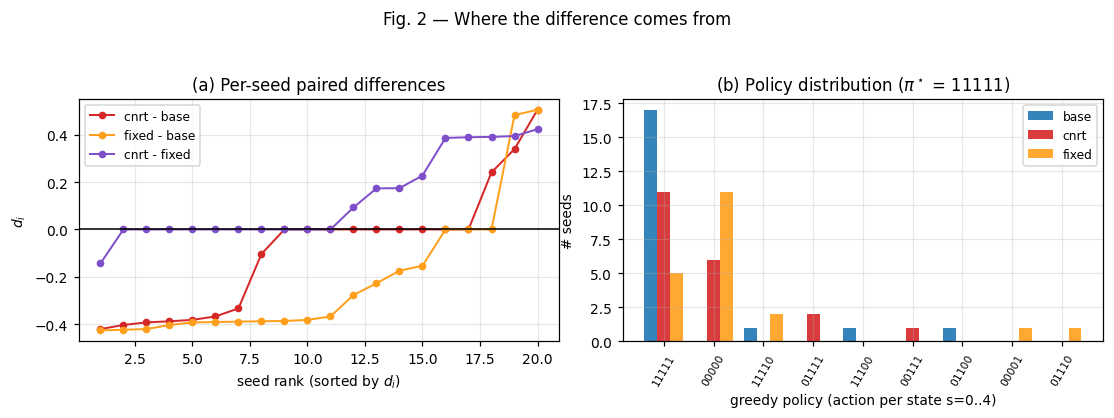

정책 표기: 상태 s=0..4 에서의 greedy action (1 = 오른쪽 = 목표 방향).  pi* = 11111


In [7]:
# ── 그림 2: 시드별 차분과 정책 분포 ──────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(10.2, 3.6))
for (a, b), c in zip(PAIRS, ["#d62728", "#ff9f1c", "#7f4fc9"]):
    d = np.sort(diffs[(a, b)])
    ax[0].plot(np.arange(1, len(d) + 1), d, marker="o", ms=4, lw=1.3, color=c,
               label=f"{a} - {b}")
ax[0].axhline(0, c="k", lw=1)
ax[0].set_xlabel("seed rank (sorted by $d_i$)"); ax[0].set_ylabel(r"$d_i$")
ax[0].set_title("(a) Per-seed paired differences"); ax[0].legend(fontsize=8)

from collections import Counter
allp = sorted({p for a in ARMS for p in res[a]["pol"]},
              key=lambda p: -sum(Counter(res[a]["pol"])[p] for a in ARMS))
lbl = ["".join(map(str, p)) for p in allp]
w = 0.26
for i, a in enumerate(ARMS):
    c = Counter(res[a]["pol"])
    ax[1].bar(np.arange(len(allp)) + (i - 1) * w, [c[p] for p in allp], w,
              color=COL[a], label=a, alpha=.9)
ax[1].set_xticks(np.arange(len(allp))); ax[1].set_xticklabels(lbl, rotation=60, fontsize=7)
ax[1].set_xlabel("greedy policy (action per state s=0..4)"); ax[1].set_ylabel("# seeds")
ax[1].set_title(r"(b) Policy distribution ($\pi^\star$ = 11111)"); ax[1].legend(fontsize=8)

fig.suptitle("Fig. 2 — Where the difference comes from", y=1.04)
plt.show()

print("정책 표기: 상태 s=0..4 에서의 greedy action (1 = 오른쪽 = 목표 방향).  pi* = 11111")

In [8]:
# ── [4] 요약 덤프 (README 자동 작성용) ───────────────────────────────────
import json, pathlib
summary = dict(
    protocol=dict(T=T_FIXED, n=N_SEEDS, seeds=[SEEDS[0], SEEDS[-1]], B=B_BOOT, alpha=ALPHA,
                  correction="Holm", crn=True),
    lemma=dict(inert_equals_base=bool(same_W1 and same_W2 and same_pi), max_dev=max_dev),
    arms={a: dict(R=float(res[a]["R"].mean()), sd=float(res[a]["R"].std(ddof=1)),
                  rho=float(res[a]["rec"].mean()), n_policies=int(len(set(res[a]["pol"]))),
                  sigma_end=float(res[a]["sigma"]),
                  wilson=[float(rec_df.iloc[i].wilson_lo), float(rec_df.iloc[i].wilson_hi)],
                  lure=int(rec_df.iloc[i]["미끼고착"]))
          for i, a in enumerate(ARMS)},
    comparisons=[dict(pair=r["비교"], meaning=r["의미"], d=float(r.d_bar),
                      ci=[float(r.ci_lo), float(r.ci_hi)], sd=float(r.sd_d),
                      p_raw=float(r.p_raw), p_holm=float(r.p_holm),
                      rej_raw=bool(r["기각(무보정)"]), rej_holm=bool(r["기각(Holm)"]),
                      n_star=(None if np.isinf(r.n_star) else int(r.n_star)),
                      wtl=[int(r.win), int(r.tie), int(r.loss)])
                 for _, r in cmp_df.iterrows()],
    d_cnrt_base=[float(v) for v in diffs[("cnrt", "base")]],
)
pathlib.Path("/tmp/day99_p1.json").write_text(json.dumps(summary, indent=1))
print(json.dumps({k: summary[k] for k in ("protocol", "lemma", "arms")}, indent=1, ensure_ascii=False))
print("\n세 가설의 운명:")
for r in summary["comparisons"]:
    print(f"  {r['pair']:>12s} ({r['meaning']}): d={r['d']:+.4f}  "
          f"CI[{r['ci'][0]:+.4f},{r['ci'][1]:+.4f}]  p_holm={r['p_holm']:.4f}  "
          f"-> {'기각(차이 있음)' if r['rej_holm'] else '기각 실패'}")

{
 "protocol": {
  "T": 10000,
  "n": 20,
  "seeds": [
   99101,
   99120
  ],
  "B": 20000,
  "alpha": 0.05,
  "correction": "Holm",
  "crn": true
 },
 "lemma": {
  "inert_equals_base": true,
  "max_dev": 0.0
 },
 "arms": {
  "base": {
   "R": 0.5283437499999999,
   "sd": 0.15263240113634044,
   "rho": 0.85,
   "n_policies": 4,
   "sigma_end": 0.125,
   "wilson": [
    0.6395767041130426,
    0.9476322080405041
   ],
   "lure": 1
  },
  "cnrt": {
   "R": 0.443234375,
   "sd": 0.18235056841308628,
   "rho": 0.55,
   "n_policies": 4,
   "sigma_end": 0.5465726776854297,
   "wilson": [
    0.3420820083075997,
    0.7418049791429071
   ],
   "lure": 9
  },
  "fixed": {
   "R": 0.31796875,
   "sd": 0.17646617656661423,
   "rho": 0.25,
   "n_policies": 5,
   "sigma_end": 0.125,
   "wilson": [
    0.11186005278940309,
    0.4687050099580636
   ],
   "lure": 13
  }
 }
}

세 가설의 운명:
     cnrt-base (+CNRT 전체 효과): d=-0.0851  CI[-0.1959,+0.0273]  p_holm=0.1500  -> 기각 실패
    fixed-base (잡음 탐색 효과 (si

## 4. 결과 해석

### (1) 세 가설 중 하나는 실험 없이 제거된다

`inert` 와 `base` 의 가중치는 **비트 단위로 일치**했다 (최대 편차 $0.0$, greedy 정책도 동일).
보조정리 2.2 가 예측한 대로다. 따라서

$$\mathbb E[R_{\texttt{inert}}] - \mathbb E[R_{\texttt{base}}] \equiv 0$$

이고, **"$+$CNRT 가 파라미터를 늘려서 좋아진다" 는 가설은 검정 대상이 아니라 이미 거짓**이다.
Noisy 헤드의 $\sigma$ 는 잡음이 주입될 때만 기울기를 받으므로, 잡음을 끄면 완전히 비활성인
파라미터다. 20 시드를 쓸 필요 없이 한 번의 `assert` 로 끝나는 통제군도 있다는 점이
이 문제의 실무적 교훈이다.

### (2) 잡음 탐색 자체가 크게 해롭다 — 그리고 그 이유는 미끼 구조에 있다

`fixed` $-$ `base` $= -0.2104$, CI $[-0.3215, -0.0820]$, $p_{\text{Holm}} = 0.0166$.
회복률은 $0.85 \to 0.25$ 로 떨어지고, **미끼 고착 시드는 $1/20 \to 13/20$** 으로 늘었다.
정책 빈도표가 기전을 보여 준다: `fixed` 의 최빈 정책은 $\pi^\star = 11111$ 이 아니라
$00000$ 이다 (11/20).

원인은 두 탐색 방식의 **상관 구조** 차이다. $\varepsilon$-greedy 는 매 스텝 독립으로
행동을 흔들므로 미끼 상태 $s=0$ 에서 벗어날 확률이 매 스텝 살아 있다. 반면 파라미터 잡음은
에피소드 단위로 **정책 전체를 일관되게** 왜곡하므로, 왼쪽으로 가는 정책이 뽑히면
그 에피소드 내내 왼쪽으로 간다. 미끼 보상 $0.25$ 는 그 궤적을 계속 강화한다.
"파라미터 공간 잡음이 심층 탐색을 준다" 는 통념은 **미끼가 있는 지형에서는 뒤집힌다**.

### (3) $\sigma$ 학습은 그 손상을 부분 복구한다

`cnrt` $-$ `fixed` $= +0.1253$, CI $[+0.0520, +0.2030]$, $p_{\text{Holm}} = 0.0166$.
학습된 $\sigma$ 는 초기값의 $\times 4.37$ ($0.125 \to 0.547$) 로 팽창했고, 그 팽창과 함께
회복률이 $0.25 \to 0.55$ 로 올라갔다. Day 98 은 이 팽창을 "감쇠 항이 없어 생긴 결함" 으로
읽었지만, 여기서는 **손상 복구와 같은 방향**으로 움직인다.

### (4) 부분은 판정되고 총합은 판정되지 않는다

`cnrt` $-$ `base` $= -0.0851$, CI $[-0.1959, +0.0273]$, $n^\star = 76$ → **확인 실패**.
분해 비교 두 개는 $n=20$ 으로 유의한데 그 **합**은 유의하지 않다. 모순이 아니라 분산 때문이다:

| 비교 | $\bar d$ | $\mathrm{sd}(d)$ | $n^\star$ |
|---|---|---|---|
| `cnrt`$-$`base` | $-0.0851$ | $0.2642$ | 76 |
| `fixed`$-$`base` | $-0.2104$ | $0.2827$ | 15 |
| `cnrt`$-$`fixed` | $+0.1253$ | $\mathbf{0.1797}$ | 17 |

두 성분이 크기는 크고 **부호가 반대**여서 합이 작아지는데, 분산은 상쇄되지 않는다.
$n^\star \propto \mathrm{sd}^2/\bar d^2$ 이므로 **총 효과가 가장 재기 어려운 양**이 된다.
Day 90–97 이 3 시드로 재려 한 것이 바로 이 총 효과였다.

승/무/패도 이산 분기를 다시 보여 준다: `cnrt`$-$`base` 는 3승 **9무** 8패 —
절반 가까운 시드에서 두 arm 이 같은 정책에 도달했고, 나머지가 크게 갈렸다.

> **결론**: $+$CNRT 의 이득은 **용량이 아니다 — 항등적으로 0 이다**. 잡음 도입은 크게 해롭고
> ($-0.21$), $\sigma$ 학습은 그 손상의 약 60 % 를 되돌리며 ($+0.13$), 둘의 합인 순 효과는
> $n=20$ 으로 판정되지 않는다 ($n^\star = 76$). **두 arm 비교로는 이 중 어느 것도 볼 수 없었다.**

**다음 문제로의 연결.** (3) 이 옳다면 Day 98 이 내놓은 처방 — $\sigma$ 를 감쇠시켜라 — 는
**복구 기전을 끄는** 처방이다. Problem 2 는 이 예측을 사전 명시하고 weight decay 세 수준과
선형 감쇠 스케줄로 검정한다. 아울러 "$\sigma$ 가 커서 좋은 것인지, $\sigma$ 를 **학습**해서
좋은 것인지" 를 가르기 위해 학습 종점과 같은 크기의 **동결** $\sigma$ 통제군을 추가한다.